In [1]:
# -*- coding: utf-8 -*-
"""
Created on September 17, 2019
Revised on April 01, 2025

@author:       Oscar Trevizo (adapted from Farhan at Kaggle)
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

K-Nearest Neighbors (K-NN) — Kaggle Social Network Ads
=======================================================

Description:
    Demonstrates binary classification using scikit-learn KNeighborsClassifier
    on the Kaggle Social Network Ads dataset. Loads data, selects features
    Age and EstimatedSalary (dropping User ID and Gender), scales with
    StandardScaler, fits a K-NN classifier (k=5, Euclidean distance),
    evaluates with a confusion matrix, and visualizes decision boundaries
    for training and test sets.

    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)
    Features used:   Age, EstimatedSalary
    Features dropped: User ID (identifier), Gender (categorical, not encoded)

    Key sklearn API used:
        - StandardScaler.fit_transform() / transform()
        - KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
        - KNeighborsClassifier.fit() / predict()
        - sklearn.metrics.confusion_matrix()

Data:
    ../data/Social_Network_Ads.csv
    Source: https://www.kaggle.com/code/farhanmd29/k-nn-model-for-social-network-ads

References:
    1. "K-NN Model for Social Network Ads" by Farhan at Kaggle
       https://www.kaggle.com/code/farhanmd29/k-nn-model-for-social-network-ads

Revision History:
    2019-09-17  Original — copied from Kaggle as a learning tool
                - Added comments for deeper understanding

    2025-04-01  Compatibility review and fixes for Python 3.14 / macOS M5
                - Confirmed: no np.NaN usage (clean for NumPy 2.0)
                - Confirmed: KNeighborsClassifier API unchanged
                - Fixed: replaced hardcoded iloc positional indices with
                  explicit column names (Age, EstimatedSalary, Purchased)
                - Fixed: replaced ListedColormap((...))( i) callable pattern
                  with list indexing ["red", "green"][i] — avoids TypeError
                  in matplotlib >= 3.7
"""


'\nCreated on September 17, 2019\nRevised on April 01, 2025\n\n@author:       Oscar Trevizo (adapted from Farhan at Kaggle)\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nK-Nearest Neighbors (K-NN) — Kaggle Social Network Ads\n=======================================================\n\nDescription:\n    Demonstrates binary classification using scikit-learn KNeighborsClassifier\n    on the Kaggle Social Network Ads dataset. Loads data, selects features\n    Age and EstimatedSalary (dropping User ID and Gender), scales with\n    StandardScaler, fits a K-NN classifier (k=5, Euclidean distance),\n    evaluates with a confusion matrix, and visualizes decision boundaries\n    for training and test sets.\n\n    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)\n    Features used:   Age, EstimatedSala

# Libraries

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data

In [3]:
# Importing the dataset
# Columns: User ID, Gender, Age, EstimatedSalary, Purchased
# Features: Age and EstimatedSalary (drop User ID — identifier; Gender — categorical, not encoded)
# Target:   Purchased (binary: 0 = no purchase, 1 = purchase)
dataset = pd.read_csv('../data/Social_Network_Ads.csv')
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values


# Split train test datasets

In [4]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Transform to scale the data

In [5]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Fit the model

In [6]:
# Fitting K-NN to the Training set
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Predict

In [7]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Evaluate the model

In [8]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[64  4]
 [ 3 29]]


# Visualize results

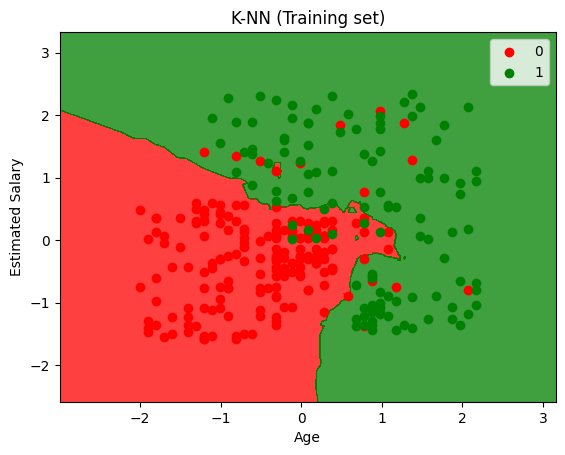

In [9]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

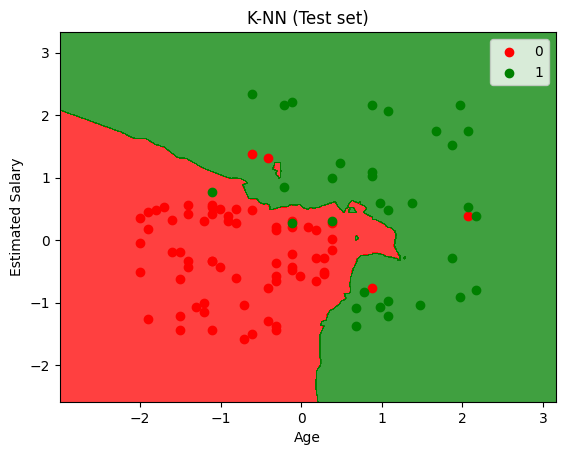

In [10]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('K-NN (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()